In [1]:
# =========================================
# Cotton Crop Disease Classification using ResNet50
# =========================================

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from tqdm import tqdm

# =========================================
# CONFIG
# =========================================

DATASET_PATH = "dataset-link-redirects-to-a-pvt-workspace, kindly-refer-to-readme-for-dataset-information"

TRAIN_DIR = os.path.join(DATASET_PATH, "train")
VALID_DIR = os.path.join(DATASET_PATH, "valid")
TEST_DIR  = os.path.join(DATASET_PATH, "test")

BATCH_SIZE = 32
IMAGE_SIZE = 224
EPOCHS = 15
LEARNING_RATE = 1e-4

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)

# =========================================
# TRANSFORMS
# =========================================

train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# =========================================
# DATASETS
# =========================================

train_dataset = datasets.ImageFolder(
    TRAIN_DIR,
    transform=train_transforms
)

valid_dataset = datasets.ImageFolder(
    VALID_DIR,
    transform=val_test_transforms
)

test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=val_test_transforms
)

# =========================================
# DATALOADERS
# =========================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

# =========================================
# CLASS NAMES
# =========================================

class_names = train_dataset.classes

print("\nClasses:")
for idx, cls in enumerate(class_names):
    print(f"{idx}: {cls}")

NUM_CLASSES = len(class_names)

# =========================================
# LOAD RESNET50
# =========================================

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

for param in model.parameters():
    param.requires_grad = True


model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

model = model.to(DEVICE)

# =========================================
# LOSS + OPTIMIZER
# =========================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)

# =========================================
# TRAIN FUNCTION
# =========================================

def train_one_epoch(model, loader):
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    loop = tqdm(loader)

    for images, labels in loop:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        loop.set_description("Training")
        loop.set_postfix(
            loss=loss.item(),
            accuracy=100. * correct / total
        )

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total

    return epoch_loss, epoch_acc

# =========================================
# VALIDATION FUNCTION
# =========================================

def validate(model, loader):
    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = outputs.max(1)

            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total

    return epoch_loss, epoch_acc

# =========================================
# TRAINING LOOP
# =========================================

best_val_acc = 0

for epoch in range(EPOCHS):

    print(f"\n========== Epoch {epoch+1}/{EPOCHS} ==========")

    train_loss, train_acc = train_one_epoch(model, train_loader)

    val_loss, val_acc = validate(model, valid_loader)

    scheduler.step(val_loss)

    print(f"\nTrain Loss: {train_loss:.4f}")
    print(f"Train Accuracy: {train_acc:.2f}%")

    print(f"\nValidation Loss: {val_loss:.4f}")
    print(f"Validation Accuracy: {val_acc:.2f}%")

    # Save best model
    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            "/kaggle/working/best_resnet50.pth"
        )

        print("\n✅ Best model saved!")

# =========================================
# TEST EVALUATION
# =========================================

print("\n========== Testing Best Model ==========")

model.load_state_dict(
    torch.load("/kaggle/working/best_resnet50.pth")
)

test_loss, test_acc = validate(model, test_loader)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")

# =========================================
# SAVE FULL MODEL
# =========================================

torch.save(model, "/kaggle/working/full_resnet50_model.pth")

print("\n✅ Training Complete!")
print("✅ Best weights saved:")
print("/kaggle/working/best_resnet50.pth")

print("\n✅ Full model saved:")
print("/kaggle/working/full_resnet50_model.pth")

Using device: cuda

Classes:
0: Aphids
1: Army worm
2: Bacterial blight
3: Cotton Boll Rot
4: Green Cotton Boll
5: Healthy
6: Powdery mildew
7: Target spot
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 169MB/s] 



========== Epoch 1/15 ==========


Training: 100%|██████████| 288/288 [01:46<00:00,  2.70it/s, accuracy=90.1, loss=0.0127]



Train Loss: 0.3844
Train Accuracy: 90.09%

Validation Loss: 0.0320
Validation Accuracy: 98.61%

✅ Best model saved!

========== Epoch 2/15 ==========


...


Train Loss: 0.0020
Train Accuracy: 99.95%

Validation Loss: 0.0072
Validation Accuracy: 99.65%

========== Epoch 14/15 ==========


Training: 100%|██████████| 288/288 [01:52<00:00,  2.55it/s, accuracy=99.9, loss=0.00152] 



Train Loss: 0.0033
Train Accuracy: 99.86%

Validation Loss: 0.0021
Validation Accuracy: 100.00%

✅ Best model saved!

========== Epoch 15/15 ==========


Training: 100%|██████████| 288/288 [01:52<00:00,  2.55it/s, accuracy=99.9, loss=0.00551] 



Train Loss: 0.0046
Train Accuracy: 99.88%

Validation Loss: 0.0057
Validation Accuracy: 99.83%

========== Testing Best Model ==========

Test Loss: 0.0198
Test Accuracy: 99.83%

✅ Training Complete!
✅ Best weights saved:
/kaggle/working/best_resnet50.pth

✅ Full model saved:
/kaggle/working/full_resnet50_model.pth


✅ Best model loaded successfully!


100%|██████████| 18/18 [00:02<00:00,  7.37it/s]



========== TEST PERFORMANCE ==========

Accuracy  : 0.9983
Precision : 0.9983
Recall    : 0.9983
F1 Score  : 0.9983
ROC AUC   : 0.9998

========== CLASSIFICATION REPORT ==========

                   precision    recall  f1-score   support

           Aphids       1.00      1.00      1.00        73
        Army worm       0.99      1.00      0.99        75
 Bacterial blight       1.00      0.98      0.99        59
  Cotton Boll Rot       1.00      1.00      1.00        74
Green Cotton Boll       1.00      1.00      1.00        78
          Healthy       1.00      1.00      1.00        69
   Powdery mildew       1.00      1.00      1.00        76
      Target spot       1.00      1.00      1.00        71

         accuracy                           1.00       575
        macro avg       1.00      1.00      1.00       575
     weighted avg       1.00      1.00      1.00       575



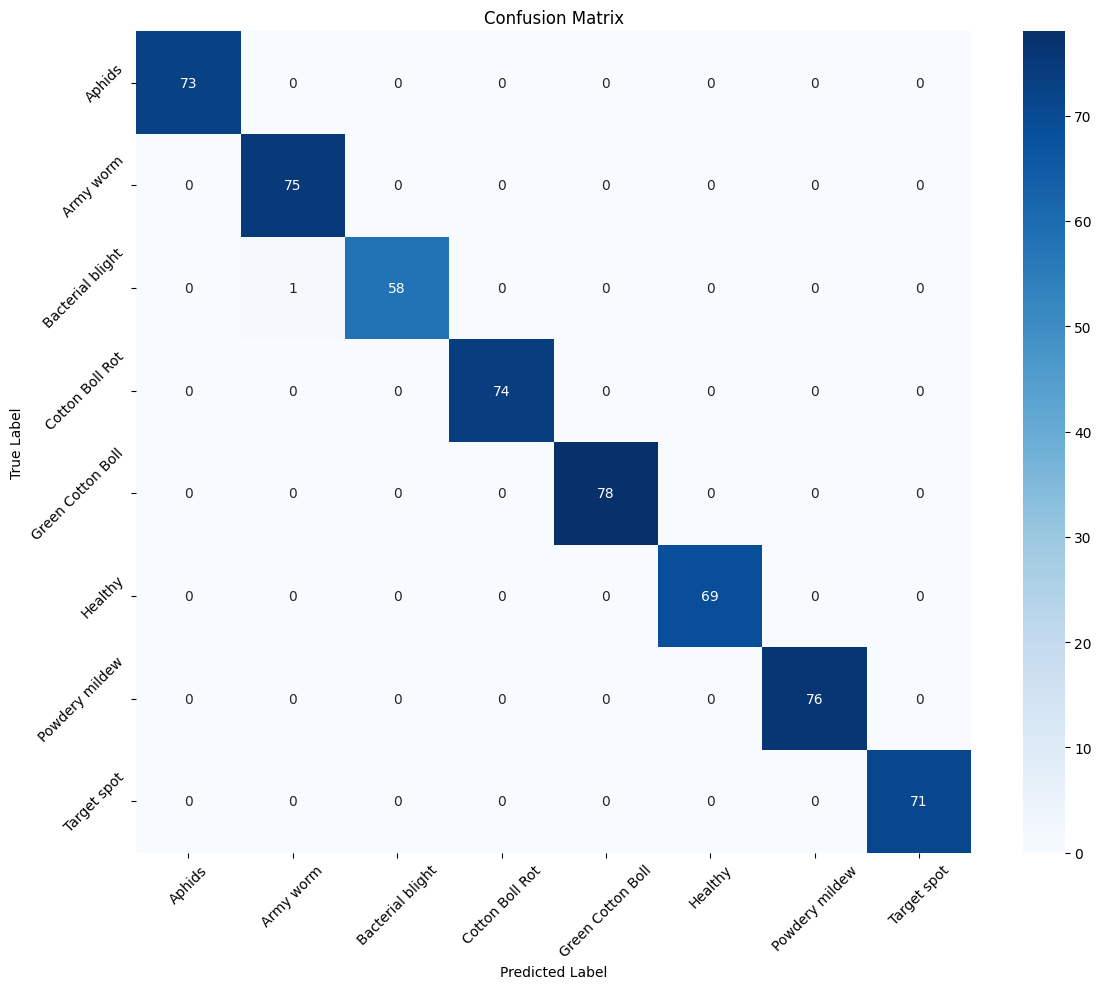


✅ Confusion matrix saved!
/kaggle/working/confusion_matrix.png

========== PER-CLASS ACCURACY ==========

Aphids: 1.0000
Army worm: 1.0000
Bacterial blight: 0.9831
Cotton Boll Rot: 1.0000
Green Cotton Boll: 1.0000
Healthy: 1.0000
Powdery mildew: 1.0000
Target spot: 1.0000

✅ Metrics saved!
/kaggle/working/test_metrics.txt


In [2]:
# =========================================
# FULL TEST EVALUATION
# =========================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

from sklearn.preprocessing import label_binarize

# =========================================
# LOAD BEST MODEL
# =========================================

model = models.resnet50(weights=None)

model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

model.load_state_dict(
    torch.load("/kaggle/working/best_resnet50.pth", map_location=DEVICE)
)

model = model.to(DEVICE)

model.eval()

print("✅ Best model loaded successfully!")

# =========================================
# TESTING
# =========================================

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():

    for images, labels in tqdm(test_loader):

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())


all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# =========================================
# METRICS
# =========================================

accuracy = accuracy_score(all_labels, all_preds)

precision = precision_score(
    all_labels,
    all_preds,
    average='weighted'
)

recall = recall_score(
    all_labels,
    all_preds,
    average='weighted'
)

f1 = f1_score(
    all_labels,
    all_preds,
    average='weighted'
)

# =========================================
# ROC AUC SCORE
# =========================================

labels_binarized = label_binarize(
    all_labels,
    classes=range(NUM_CLASSES)
)

roc_auc = roc_auc_score(
    labels_binarized,
    all_probs,
    multi_class='ovr'
)

# =========================================
# PRINT RESULTS
# =========================================

print("\n========== TEST PERFORMANCE ==========")

print(f"\nAccuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC AUC   : {roc_auc:.4f}")

# =========================================
# CLASSIFICATION REPORT
# =========================================

print("\n========== CLASSIFICATION REPORT ==========\n")

print(classification_report(
    all_labels,
    all_preds,
    target_names=class_names
))

# =========================================
# CONFUSION MATRIX
# =========================================

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.xticks(rotation=45)
plt.yticks(rotation=45)

plt.tight_layout()


plt.savefig("/kaggle/working/confusion_matrix.png")

plt.show()

print("\n✅ Confusion matrix saved!")
print("/kaggle/working/confusion_matrix.png")

# =========================================
# PER-CLASS ACCURACY
# =========================================

print("\n========== PER-CLASS ACCURACY ==========\n")

for i, class_name in enumerate(class_names):

    class_total = cm[i].sum()

    class_correct = cm[i][i]

    class_acc = class_correct / class_total

    print(f"{class_name}: {class_acc:.4f}")

# =========================================
# SAVE METRICS TO TXT FILE
# =========================================

with open("/kaggle/working/test_metrics.txt", "w") as f:

    f.write("========== TEST PERFORMANCE ==========\n\n")

    f.write(f"Accuracy  : {accuracy:.4f}\n")
    f.write(f"Precision : {precision:.4f}\n")
    f.write(f"Recall    : {recall:.4f}\n")
    f.write(f"F1 Score  : {f1:.4f}\n")
    f.write(f"ROC AUC   : {roc_auc:.4f}\n\n")

    f.write("========== CLASSIFICATION REPORT ==========\n\n")

    f.write(classification_report(
        all_labels,
        all_preds,
        target_names=class_names
    ))

print("\n✅ Metrics saved!")
print("/kaggle/working/test_metrics.txt")

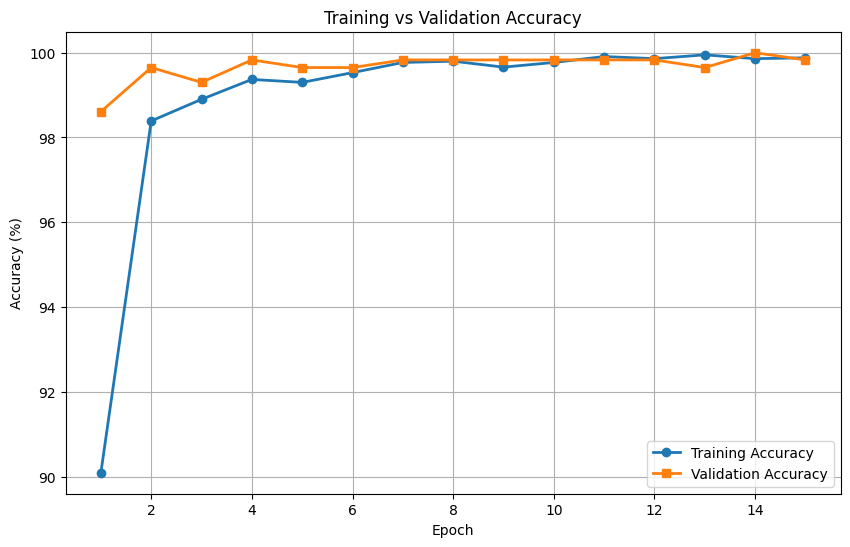

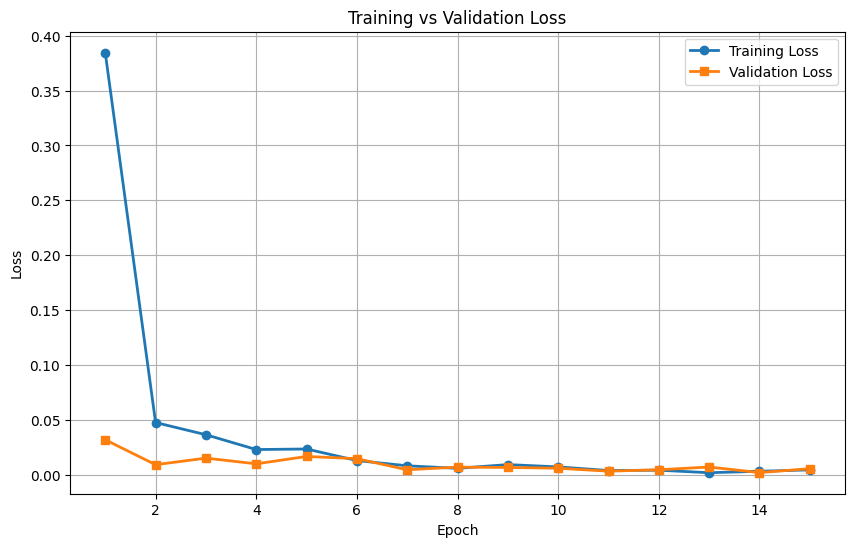

✅ Accuracy curve saved:
/kaggle/working/accuracy_curve.png

✅ Loss curve saved:
/kaggle/working/loss_curve.png


In [3]:
# =========================================
# TRAINING HISTORY PLOTS, DATA INFERRED FROM HISTORY OBTAINED DURING TRAINING
# =========================================

import matplotlib.pyplot as plt

# =========================================
# MANUALLY ADD YOUR HISTORY
# =========================================

epochs = list(range(1, 16))

train_acc = [
    90.09,
    98.39,
    98.90,
    99.37,
    99.30,
    99.53,
    99.77,
    99.80,
    99.66,
    99.77,
    99.91,
    99.86,
    99.95,
    99.86,
    99.88
]

val_acc = [
    98.61,
    99.65,
    99.30,
    99.83,
    99.65,
    99.65,
    99.83,
    99.83,
    99.83,
    99.83,
    99.83,
    99.83,
    99.65,
    100.00,
    99.83
]

train_loss = [
    0.3844,
    0.0477,
    0.0366,
    0.0231,
    0.0236,
    0.0131,
    0.0083,
    0.0060,
    0.0094,
    0.0073,
    0.0040,
    0.0043,
    0.0020,
    0.0033,
    0.0046
]

val_loss = [
    0.0320,
    0.0093,
    0.0153,
    0.0101,
    0.0168,
    0.0148,
    0.0047,
    0.0071,
    0.0068,
    0.0061,
    0.0034,
    0.0047,
    0.0072,
    0.0021,
    0.0057
]

# =========================================
# ACCURACY CURVE
# =========================================

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    train_acc,
    marker='o',
    linewidth=2,
    label='Training Accuracy'
)

plt.plot(
    epochs,
    val_acc,
    marker='s',
    linewidth=2,
    label='Validation Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.savefig("/kaggle/working/accuracy_curve.png")

plt.show()

# =========================================
# LOSS CURVE
# =========================================

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    train_loss,
    marker='o',
    linewidth=2,
    label='Training Loss'
)

plt.plot(
    epochs,
    val_loss,
    marker='s',
    linewidth=2,
    label='Validation Loss'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.savefig("/kaggle/working/loss_curve.png")

plt.show()

print("✅ Accuracy curve saved:")
print("/kaggle/working/accuracy_curve.png")

print("\n✅ Loss curve saved:")
print("/kaggle/working/loss_curve.png")